In [31]:
%matplotlib widget

import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mplcursors

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [32]:
BASE_URL = "http://127.0.0.1:8080/pypi"

# Endpoints
TOTAL_PACKAGES_ENDPOINT = f"{BASE_URL}/total-packages"
PACKAGE_VERSIONS_ENDPOINT = f"{BASE_URL}/package-versions"
RELEASES_OVER_YEARS_ENDPOINT = f"{BASE_URL}/releases-over-years"
ALL_SOURCES_COVERAGE_ENDPOINT = f"{BASE_URL}/all_sources_coverage"

# Function to get JSON from API
def get_json(endpoint):
    resp = requests.get(endpoint)
    resp.raise_for_status()
    return resp.json()

Total PyPI packages: 82


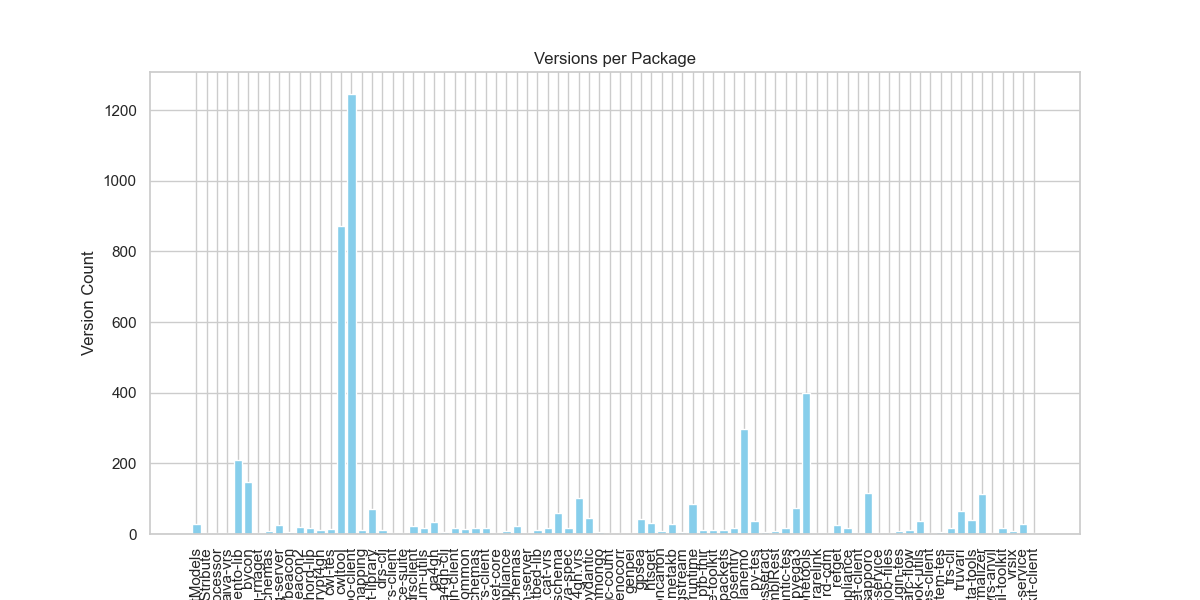

In [41]:
# -------------------------------------------
# 1. Total packages
# -------------------------------------------

total_packages = get_json(TOTAL_PACKAGES_ENDPOINT)["total_packages"]
print(f"Total PyPI packages: {total_packages}")

# -------------------------------------------
# 2. Packages versions
# -------------------------------------------
package_versions = get_json(PACKAGE_VERSIONS_ENDPOINT)
df_versions = pd.DataFrame(package_versions)

fig, ax = plt.subplots()
bars = ax.bar(df_versions['package_name'], df_versions['versions'], color="skyblue")
ax.set_title("Versions per Package")
ax.set_xlabel("Package")
ax.set_ylabel("Version Count")
ax.tick_params(axis='x', rotation=90)

cursor = mplcursors.cursor(bars, hover=True)
@cursor.connect("add")
def on_add(sel):
    pkg = df_versions['package_name'].iloc[sel.index]
    ver_count = df_versions['versions'].iloc[sel.index]
    sel.annotation.set_text(f"{pkg}: {ver_count}")

plt.show()

   year  releases
0  2013         2
1  2014        12
2  2015       286
3  2016       344
4  2017       202


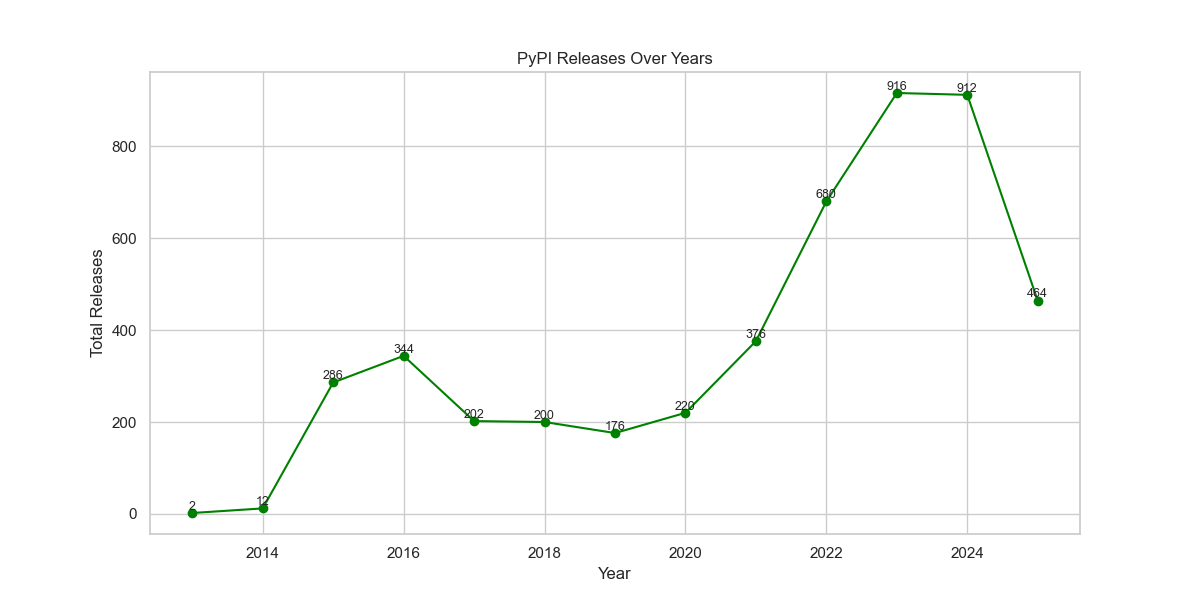

In [37]:
# -------------------------------------------
# 3. Releases Over Years
# -------------------------------------------
resp = requests.get(f"{BASE_URL}/releases-over-years")
resp.raise_for_status()
releases_data = resp.json()
df_releases = pd.DataFrame(releases_data["releases_over_years"])
print(df_releases.head())

fig, ax = plt.subplots()
ax.plot(df_releases["year"], df_releases["releases"], marker="o", color="green", linestyle="-")
ax.set_xlabel("Year")
ax.set_ylabel("Total Releases")
ax.set_title("PyPI Releases Over Years")

for i, row in df_releases.iterrows():
    ax.text(
        row["year"], 
        row["releases"] + 0.5,
        str(row["releases"]), 
        ha="center", va="bottom", fontsize=9
    )

plt.show()

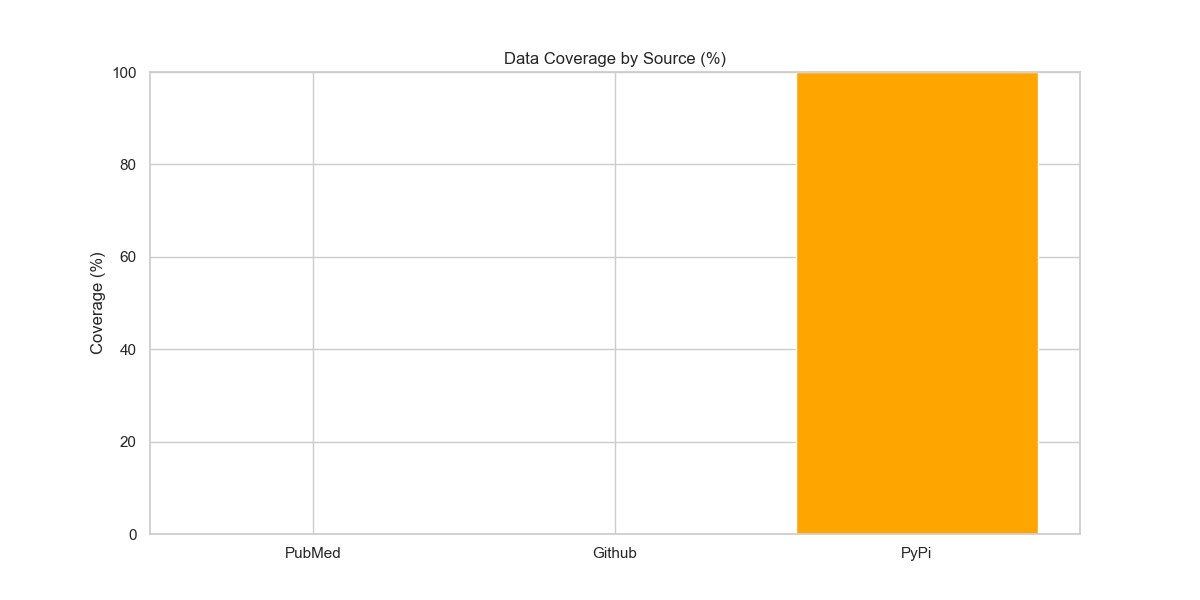

In [22]:
# -------------------------------------------
# 4. All Sources Coverage
# -------------------------------------------
resp = requests.get(f"{BASE_URL}/all_sources_coverage")
resp.raise_for_status()
coverage_data = resp.json()
df_coverage = pd.DataFrame(coverage_data["coverages"])
df_coverage["uncovered_records"] = df_coverage["total_records"] - df_coverage["covered_records"]

# Coverage Percent Bar
fig, ax = plt.subplots()
bars = ax.bar(df_coverage["source"], df_coverage["coverage_percent"], color="orange")
ax.set_title("Data Coverage by Source (%)")
ax.set_ylabel("Coverage (%)")
ax.set_ylim(0, 100)

cursor = mplcursors.cursor(bars, hover=True)
@cursor.connect("add")
def on_add(sel):
    source = df_coverage["source"].iloc[sel.index]
    percent = df_coverage["coverage_percent"].iloc[sel.index]
    sel.annotation.set_text(f"{source}: {percent:.2f}%")

plt.show()

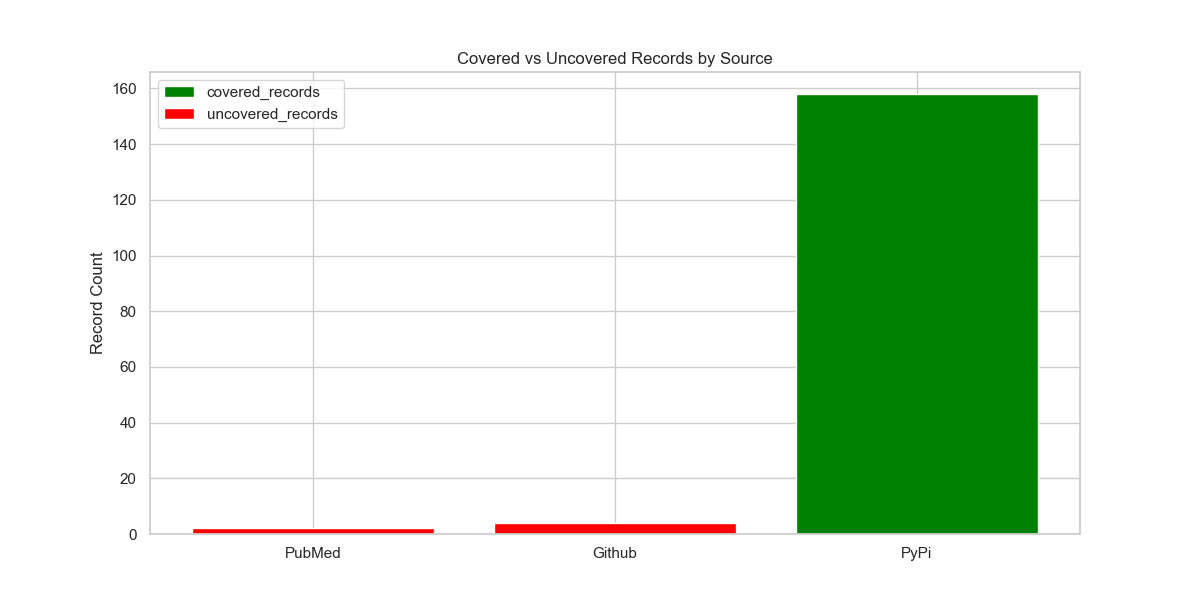

In [24]:
# Stacked Bar: Covered vs Uncovered Records
df_coverage_plot = df_coverage.melt(
    id_vars="source",
    value_vars=["covered_records", "uncovered_records"],
    var_name="status",
    value_name="count"
)

fig, ax = plt.subplots()
colors = {"covered_records": "green", "uncovered_records": "red"}
for status, grp in df_coverage_plot.groupby("status"):
    ax.bar(grp["source"], grp["count"], label=status, color=colors[status], bottom=grp.groupby("source")["count"].cumsum() - grp["count"])

ax.set_title("Covered vs Uncovered Records by Source")
ax.set_ylabel("Record Count")
ax.legend()

plt.show()
